# Model Training — Soil & Fertilizer

1. Load feature-engineered data
2. Train-test split
3. Train multiple models (Random Forest, XGBoost, Logistic Regression, SVM)
4. Evaluate and compare models

**Note:** Run `feature_engineering.ipynb` first to create `X_fe` and `y`, or run the load cell below.

## Load feature-engineered data

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

DATA_PATH = "../data/data/raw/data_core.csv"
TARGET_COL = "Fertilizer Name"

# Load and clean
df = pd.read_csv(DATA_PATH)
df = df.fillna(df.mean(numeric_only=True)).fillna("Unknown")
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Encode categoricals
X_encoded = pd.get_dummies(X, columns=["Soil Type", "Crop Type"], prefix=["Soil", "Crop"])

# Add new features
X_fe = X_encoded.copy()
X_fe["NPK_total"] = X_fe["Nitrogen"] + X_fe["Phosphorous"] + X_fe["Potassium"]
X_fe["Temp_Humidity"] = X_fe["Temperature"] * X_fe["Humidity"]
X_fe["Moisture_level"] = pd.qcut(X_fe["Moisture"], q=3, labels=["Low", "Medium", "High"])
X_fe = pd.get_dummies(X_fe, columns=["Moisture_level"], prefix="Moisture")

# Scale numeric features
to_scale = ["Temperature", "Humidity", "Moisture", "Nitrogen", "Potassium", "Phosphorous", "NPK_total", "Temp_Humidity"]
to_scale = [c for c in to_scale if c in X_fe.columns]
scaler = StandardScaler()
X_fe[to_scale] = scaler.fit_transform(X_fe[to_scale])

print("Feature matrix shape:", X_fe.shape)
print("Target shape:", y.shape)
print("Unique fertilizers:", y.nunique())

Feature matrix shape: (8000, 27)
Target shape: (8000,)
Unique fertilizers: 7


## Train-Test Split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

Training set: 6400 samples
Test set: 1600 samples
Features: 27


## Train Models

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# Initialize models (XGBoost optional - install with: pip install xgboost)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    "SVM": SVC(random_state=42, probability=True)
}
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(random_state=42, eval_metric='mlogloss')
except ImportError:
    print("XGBoost not installed (pip install xgboost for full comparison)\n")

# Train all models
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✓ {name} trained\n")

XGBoost not installed (pip install xgboost for full comparison)

Training Random Forest...


✓ Random Forest trained

Training Logistic Regression...


✓ Logistic Regression trained

Training SVM...


✓ SVM trained



## Evaluate Models

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    }

# Display results
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)
print("\n=== Model Comparison ===")
print(results_df.round(4))


=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.1431     0.1427  0.1431    0.1402
Random Forest          0.1406     0.1404  0.1406    0.1402
SVM                    0.1362     0.1372  0.1362    0.1357


## Detailed Evaluation — Best Model

In [5]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"\nBest Model: {best_model_name}")
print(f"\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)

print(f"\n=== Classification Report ===")
print(classification_report(y_test, y_pred_best))


Best Model: Logistic Regression

=== Confusion Matrix ===
[[31 30 34 31 17 40 43]
 [37 28 32 26 22 40 53]
 [31 25 26 19 26 50 48]
 [26 25 29 25 25 54 36]
 [36 34 16 23 22 43 50]
 [32 35 34 16 18 51 47]
 [34 36 28 20 20 50 46]]

=== Classification Report ===
              precision    recall  f1-score   support

    10-26-26       0.14      0.14      0.14       226
    14-35-14       0.13      0.12      0.12       238
    17-17-17       0.13      0.12      0.12       225
       20-20       0.16      0.11      0.13       220
       28-28       0.15      0.10      0.12       224
         DAP       0.16      0.22      0.18       233
        Urea       0.14      0.20      0.17       234

    accuracy                           0.14      1600
   macro avg       0.14      0.14      0.14      1600
weighted avg       0.14      0.14      0.14      1600



## Visualize Confusion Matrix

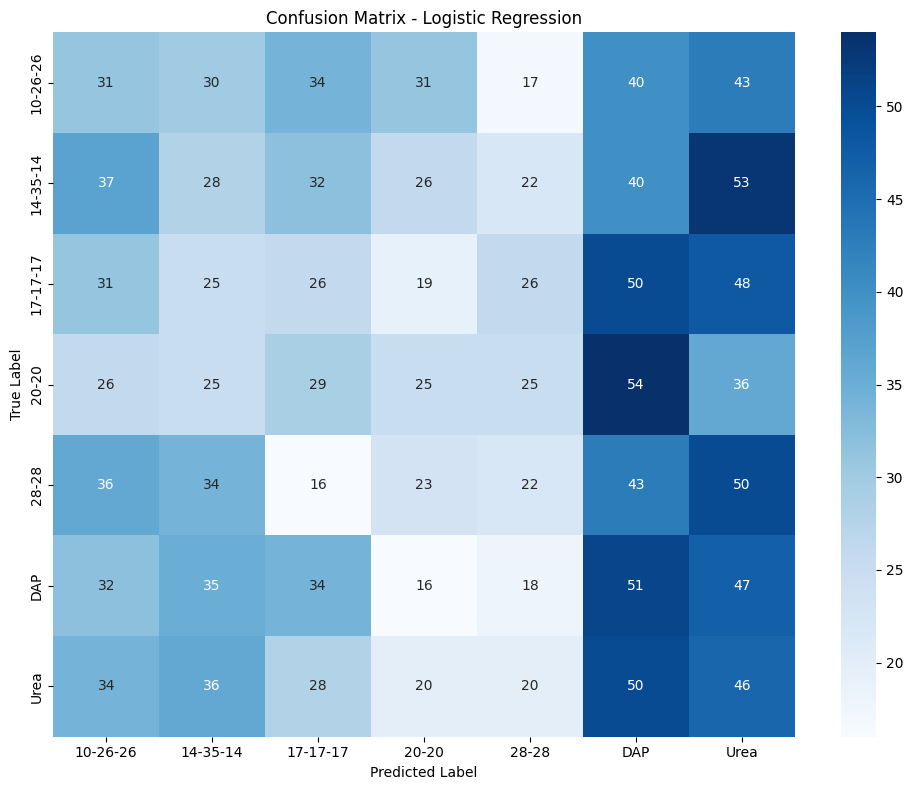

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y_test.unique()), 
            yticklabels=sorted(y_test.unique()))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Save Best Model

In [7]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save model and scaler
model_path = f"../models/{best_model_name.lower().replace(' ', '_')}_model.pkl"
scaler_path = "../models/scaler.pkl"

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"✓ Model saved: {model_path}")
print(f"✓ Scaler saved: {scaler_path}")

✓ Model saved: ../models/logistic_regression_model.pkl
✓ Scaler saved: ../models/scaler.pkl
